# Spontaneous Remission Statistical Analysis

**Purpose:** Validate the "Somatic Influx" hypothesis - spiritual transformation as causal precursor to spontaneous remission

**Dataset:** 569 cases from PMC (350), Radical Remission Project (149), NDERF (50), IANDS (20)

**Date:** January 2, 2026

---

## Core Hypothesis

The correspondential framework predicts:
1. **Spiritual transformation consistently precedes physical healing**
2. **Psycho-spiritual factors (Turner's 7 of 9) dominate over physical factors**
3. **Disease-spirit correspondences are systematic, not random**
4. **Healing magnitude exceeds placebo baseline**

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# Load all analyzed cases
analysis_path = Path('output/analysis')
records = []

for json_file in analysis_path.glob('*.json'):
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            record = json.load(f)
            records.append(record)
    except Exception as e:
        print(f"Error loading {json_file.name}: {e}")

print(f"✓ Loaded {len(records)} cases")

✓ Loaded 569 cases


In [3]:
# Extract flat data from nested structure
def extract_case_data(record):
    """Flatten the nested JSON into a row for DataFrame."""
    analysis = record.get('analysis', {}) or {}
    
    data = {
        'dataset': record.get('dataset', 'unknown'),
        'title': record.get('title', ''),
    }
    
    # Demographics
    demo = analysis.get('demographics', {}) or {}
    data['age_at_diagnosis'] = demo.get('age_at_diagnosis')
    data['sex'] = demo.get('sex', 'not_mentioned')
    data['religious_background'] = demo.get('religious_background', 'not_mentioned')
    
    # Diagnosis
    diag = analysis.get('diagnosis', {}) or {}
    data['disease_category'] = diag.get('disease_category', 'unknown')
    data['cancer_type'] = diag.get('cancer_type', 'not_applicable')
    data['cancer_stage'] = diag.get('cancer_stage', 'unknown')
    data['organ_system'] = diag.get('organ_system', 'other')
    data['considered_terminal'] = diag.get('considered_terminal', 'not_mentioned')
    
    # Treatment
    treat = analysis.get('treatment', {}) or {}
    data['conventional_status'] = treat.get('conventional_status', 'not_mentioned')
    
    # Remission outcome
    outcome = analysis.get('remission_outcome', {}) or {}
    data['remission_type'] = outcome.get('remission_type', 'not_specified')
    data['remission_category'] = outcome.get('remission_category', 'not_determinable')
    data['remission_speed'] = outcome.get('remission_speed', 'not_specified')
    data['verification_tier'] = analysis.get('validation', {}).get('verification_tier', 'unknown')
    data['durability'] = outcome.get('durability', 'unknown')
    data['follow_up_months'] = outcome.get('follow_up_duration_months')
    
    # Turner factors
    tf = analysis.get('turner_factors', {}) or {}
    for factor in ['diet_change', 'agency', 'intuition', 'supplements', 
                   'emotional_release', 'positive_emotions', 'social_support',
                   'spiritual_connection', 'purpose']:
        data[f'factor_{factor}'] = tf.get(f'factor_{factor}', 'not_mentioned')
    data['factors_count'] = tf.get('factors_present_count', 0)
    
    # Existential shift
    es = analysis.get('existential_shift', {}) or {}
    data['transformation_preceded'] = es.get('transformation_preceded_healing', 'not_mentioned')
    data['identity_shift'] = es.get('identity_shift', 'not_mentioned')
    data['fear_to_love_shift'] = es.get('fear_to_love_shift', 'not_mentioned')
    data['surrender_event'] = es.get('surrender_event', 'not_mentioned')
    
    # Anomalous experience
    ae = analysis.get('anomalous_experience', {}) or {}
    data['anomalous_type'] = ae.get('experience_type', 'not_mentioned')
    data['experience_preceded'] = ae.get('experience_preceded_healing', 'not_mentioned')
    
    # Flags
    data['is_verified'] = analysis.get('is_verified_remission', False)
    data['is_pure_spontaneous'] = analysis.get('is_pure_spontaneous', False)
    data['has_transformation'] = analysis.get('has_transformation_narrative', False)
    data['has_temporal_sequence'] = analysis.get('has_temporal_sequence', False)
    
    return data

# Build DataFrame
df = pd.DataFrame([extract_case_data(r) for r in records])
print(f"✓ DataFrame: {len(df)} rows × {len(df.columns)} columns")

✓ DataFrame: 569 rows × 37 columns


## 2. Dataset Overview

Basic statistics on case distribution by source, disease category, and verification tier.

Cases by Source:
dataset
pmc      350
rrp      149
nderf     50
iands     20
Name: count, dtype: int64

Cases by Disease Category:
disease_category
cancer              361
other                64
autoimmune           22
cardiovascular       16
musculoskeletal      15
hematological        15
infectious           14
neurological         13
endocrine             9
dermatological        8
gastrointestinal      8
unknown               7
congenital            7
renal                 5
respiratory           5
Name: count, dtype: int64

Cases by Verification Tier:
verification_tier
tier_2_clinical         232
tier_1_institutional    128
tier_4_anecdotal        107
tier_3_detailed         102
Name: count, dtype: int64


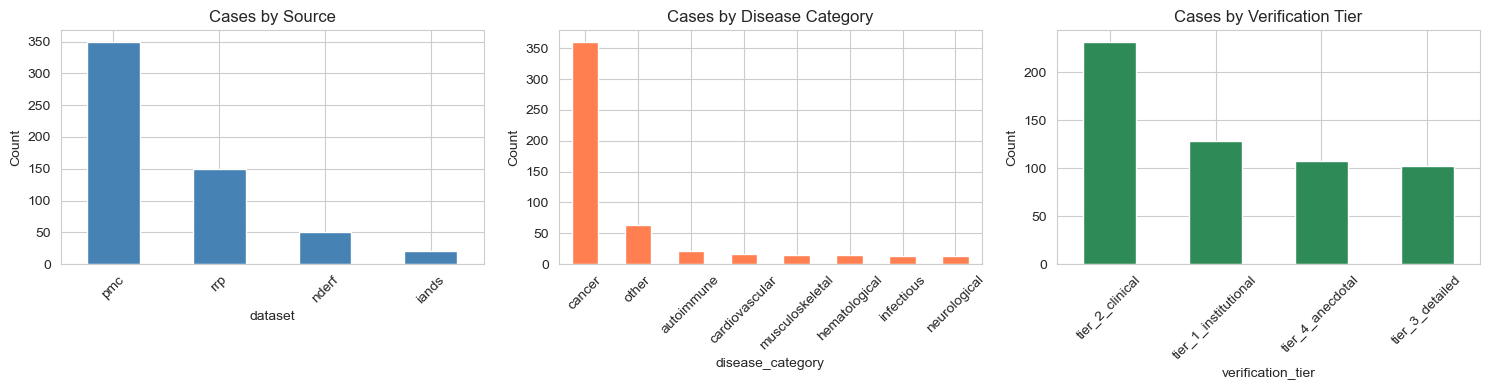

In [4]:
# Source distribution
source_counts = df['dataset'].value_counts()
print("Cases by Source:")
print(source_counts)
print()

# Disease category distribution
disease_counts = df['disease_category'].value_counts()
print("Cases by Disease Category:")
print(disease_counts)
print()

# Verification tier distribution
tier_counts = df['verification_tier'].value_counts()
print("Cases by Verification Tier:")
print(tier_counts)

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

source_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Cases by Source')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

disease_counts.head(8).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Cases by Disease Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

tier_counts.plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Cases by Verification Tier')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Turner's 9 Factors Analysis

Analyzing prevalence and co-occurrence of Turner's radical remission factors.

Sample factor values:
  factor_diet_change: {'not_mentioned': 441, 'yes_explicit': 76, 'no': 27, 'implied': 25}
  factor_agency: {'not_mentioned': 266, 'yes_explicit': 176, 'implied': 113, 'no': 14}
  factor_intuition: {'not_mentioned': 437, 'yes_explicit': 69, 'implied': 55, 'no': 8}

Turner Factor Prevalence:
              Factor  Prevalence (%)
              Agency       50.790861
             Purpose       31.107206
   Positive Emotions       31.107206
Spiritual Connection       29.173989
      Social Support       26.713533
           Intuition       21.792619
         Diet Change       17.750439
   Emotional Release       15.641476
         Supplements       14.235501


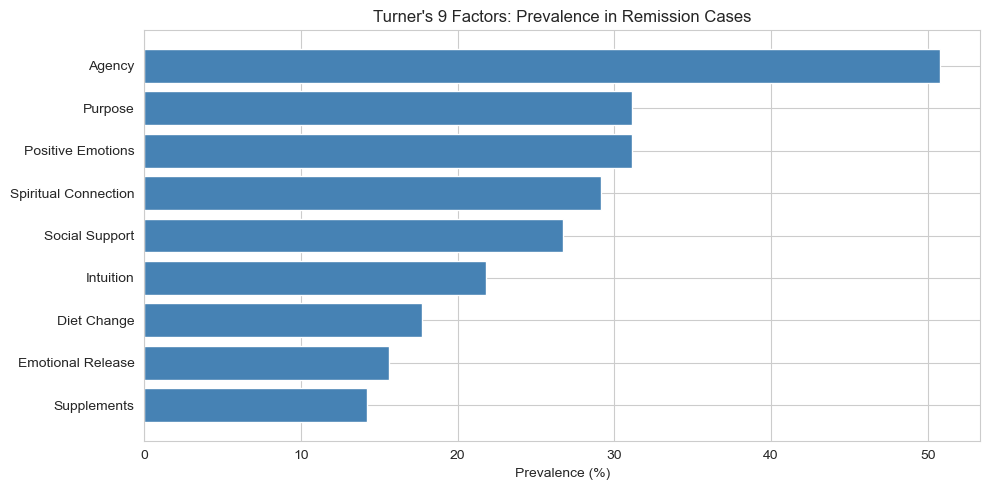

In [6]:
# Calculate factor prevalence
factor_cols = [c for c in df.columns if c.startswith('factor_') and c != 'factors_count']
factor_names = [c.replace('factor_', '').replace('_', ' ').title() for c in factor_cols]

# Check actual values in the data
print("Sample factor values:")
for col in factor_cols[:3]:
    print(f"  {col}: {df[col].value_counts().to_dict()}")

# Count 'yes_explicit' or 'implied' as present
def is_present(val):
    return val in ['yes_explicit', 'implied', 'present']

factor_prevalence = {}
for col, name in zip(factor_cols, factor_names):
    present_count = df[col].apply(is_present).sum()
    factor_prevalence[name] = present_count / len(df) * 100

# Sort by prevalence
factor_df = pd.DataFrame({
    'Factor': list(factor_prevalence.keys()),
    'Prevalence (%)': list(factor_prevalence.values())
}).sort_values('Prevalence (%)', ascending=False)

print("\nTurner Factor Prevalence:")
print(factor_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(factor_df['Factor'], factor_df['Prevalence (%)'], color='steelblue')
ax.set_xlabel('Prevalence (%)')
ax.set_title("Turner's 9 Factors: Prevalence in Remission Cases")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Factor Count Distribution:
factors_count
0.0    196
1.0    113
2.0     43
3.0     35
4.0     52
5.0     32
6.0     40
7.0     22
8.0     12
9.0      5
Name: count, dtype: int64

Mean factors: 2.19
Median factors: 1


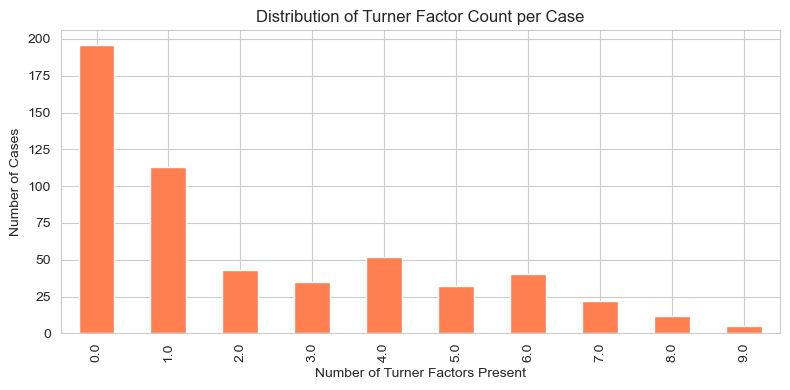

In [7]:
# Factor count distribution
factor_count_dist = df['factors_count'].value_counts().sort_index()
print("Factor Count Distribution:")
print(factor_count_dist)
print(f"\nMean factors: {df['factors_count'].mean():.2f}")
print(f"Median factors: {df['factors_count'].median():.0f}")

# Plot factor count distribution
fig, ax = plt.subplots(figsize=(8, 4))
factor_count_dist.plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Number of Turner Factors Present')
ax.set_ylabel('Number of Cases')
ax.set_title('Distribution of Turner Factor Count per Case')
plt.tight_layout()
plt.show()

C:\Users\mlf\AppData\Local\Temp\ipykernel_29380\3315971456.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  factor_binary = df[factor_cols].applymap(lambda x: 1 if x in ['yes_explicit', 'implied', 'present'] else 0)


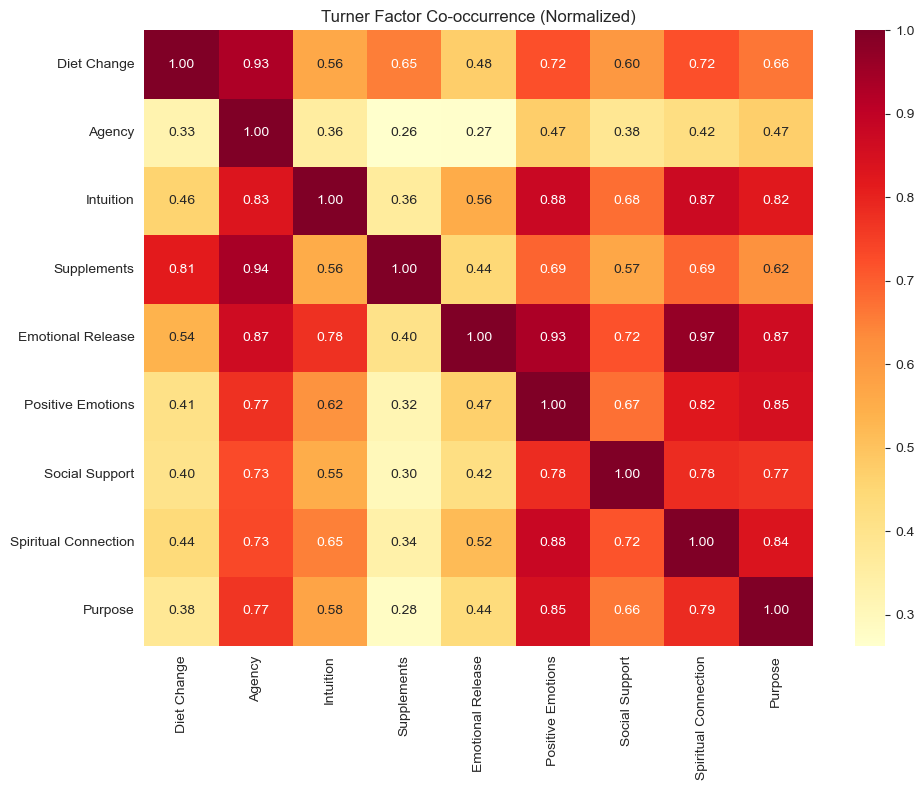

In [8]:
# Factor co-occurrence matrix
factor_binary = df[factor_cols].applymap(lambda x: 1 if x in ['yes_explicit', 'implied', 'present'] else 0)
cooccurrence = factor_binary.T.dot(factor_binary)

# Normalize by diagonal (frequency of each factor)
diag = np.diag(cooccurrence).copy()
diag[diag == 0] = 1  # avoid divide by zero
cooccurrence_norm = cooccurrence / diag[:, None]

# Rename for display
cooccurrence_norm.index = factor_names
cooccurrence_norm.columns = factor_names

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooccurrence_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Turner Factor Co-occurrence (Normalized)')
plt.tight_layout()
plt.show()

## 4. Transformation → Healing Sequence Analysis

**Core Hypothesis**: Spiritual/psychological transformation *precedes* physical healing, consistent with the "Somatic Influx" model where consciousness changes causally affect somatic outcomes.

Transformation Preceded Healing:
transformation_preceded
not_mentioned    425
implied          113
no                22
yes_explicit       9
Name: count, dtype: int64

Among cases WITH transformation narrative (n=206):
transformation_preceded
implied          112
not_mentioned     65
no                20
yes_explicit       9
Name: count, dtype: int64


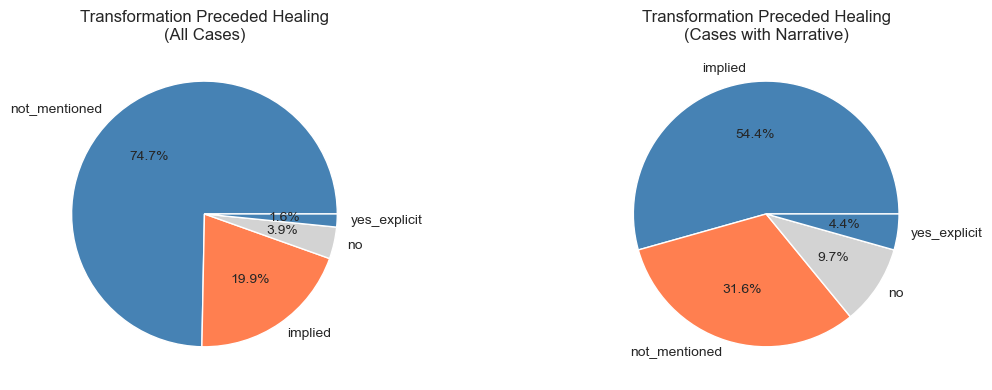

In [9]:
# Transformation preceded healing analysis
transform_status = df['transformation_preceded'].value_counts()
print("Transformation Preceded Healing:")
print(transform_status)
print()

# Among cases with transformation narrative
with_narrative = df[df['has_transformation'] == True]
transform_in_narrative = with_narrative['transformation_preceded'].value_counts()
print(f"Among cases WITH transformation narrative (n={len(with_narrative)}):")
print(transform_in_narrative)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

transform_status.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['steelblue', 'coral', 'lightgray'])
axes[0].set_title('Transformation Preceded Healing\n(All Cases)')
axes[0].set_ylabel('')

if len(with_narrative) > 0:
    transform_in_narrative.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'coral', 'lightgray'])
    axes[1].set_title('Transformation Preceded Healing\n(Cases with Narrative)')
    axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [11]:
# Existential shift markers
shift_markers = ['identity_shift', 'fear_to_love_shift', 'surrender_event']

print("Existential Shift Markers Prevalence:")
for marker in shift_markers:
    present = df[marker].isin(['yes_explicit', 'implied', 'present']).sum()
    pct = present / len(df) * 100
    print(f"  {marker.replace('_', ' ').title()}: {present} ({pct:.1f}%)")
    print(f"    Values: {df[marker].value_counts().to_dict()}")

# Cross-tabulation: shift markers vs transformation preceded
print("\nCross-tabulation: Surrender Event × Transformation Preceded")
crosstab = pd.crosstab(df['surrender_event'], df['transformation_preceded'])
print(crosstab)

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(crosstab)
print(f"\nChi-square: {chi2:.2f}, p-value: {p:.6f}")

Existential Shift Markers Prevalence:
  Identity Shift: 132 (23.2%)
    Values: {'not_mentioned': 437, 'implied': 90, 'yes_explicit': 42}
  Fear To Love Shift: 106 (18.6%)
    Values: {'not_mentioned': 462, 'implied': 75, 'yes_explicit': 31, 'no': 1}
  Surrender Event: 58 (10.2%)
    Values: {'not_mentioned': 508, 'implied': 38, 'yes_explicit': 20, 'no': 3}

Cross-tabulation: Surrender Event × Transformation Preceded
transformation_preceded  implied  no  not_mentioned  yes_explicit
surrender_event                                                  
implied                       21   5              9             3
no                             2   0              1             0
not_mentioned                 75  14            414             5
yes_explicit                  15   3              1             1

Chi-square: 123.51, p-value: 0.000000


## 5. Anomalous Experiences Analysis

Examining NDEs and other anomalous experiences in relation to remission.

Anomalous Experience Types:
anomalous_type
none                   254
not_mentioned          223
nde                     65
mystical_experience      8
synchronicity            5
profound_dream           4
obe                      4
voice_hearing            3
healing_service          2
encounter_deceased       1
Name: count, dtype: int64

Anomamous Experience Preceded Healing:
experience_preceded
not_mentioned    437
yes_explicit      50
no                43
implied           39
Name: count, dtype: int64

Cases with Anomalous Experience: 346 (60.8%)
Among these, experience preceded healing:
experience_preceded
not_mentioned    214
yes_explicit      50
no                43
implied           39
Name: count, dtype: int64


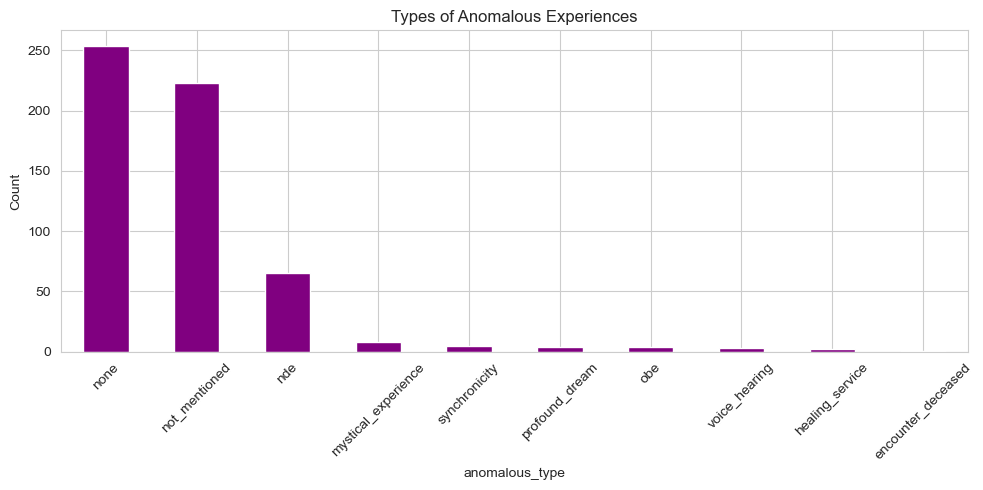

In [12]:
# Anomalous experience types
ae_types = df['anomalous_type'].value_counts()
print("Anomalous Experience Types:")
print(ae_types)

# Experience preceded healing
ae_preceded = df['experience_preceded'].value_counts()
print("\nAnomamous Experience Preceded Healing:")
print(ae_preceded)

# Filter to only cases with anomalous experience (not 'not_mentioned')
has_ae = df[df['anomalous_type'] != 'not_mentioned']
print(f"\nCases with Anomalous Experience: {len(has_ae)} ({len(has_ae)/len(df)*100:.1f}%)")

# Among these, how many had experience precede healing?
if len(has_ae) > 0:
    ae_preceded_in_ae = has_ae['experience_preceded'].value_counts()
    print("Among these, experience preceded healing:")
    print(ae_preceded_in_ae)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ae_types.plot(kind='bar', ax=ax, color='purple')
ax.set_title('Types of Anomalous Experiences')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Source Comparison Analysis

Comparing patterns across different data sources (PMC medical literature vs. testimonial sources).

Turner Factor Prevalence by Source (%):
Source   N  Diet Change    Agency  Intuition  Supplements  Emotional Release  Positive Emotions  Social Support  Spiritual Connection   Purpose
 iands  20     0.000000 50.000000  60.000000     5.000000          45.000000          90.000000       70.000000            100.000000 95.000000
 nderf  50     4.000000 32.000000  56.000000     2.000000          36.000000          80.000000       88.000000             92.000000 80.000000
   pmc 350     3.714286 35.142857   0.857143     3.714286           0.285714           1.428571        4.000000              0.285714  1.428571
   rrp 149    57.718121 93.959732  54.362416    44.295302          40.939597          76.510067       53.691275             66.442953 75.838926


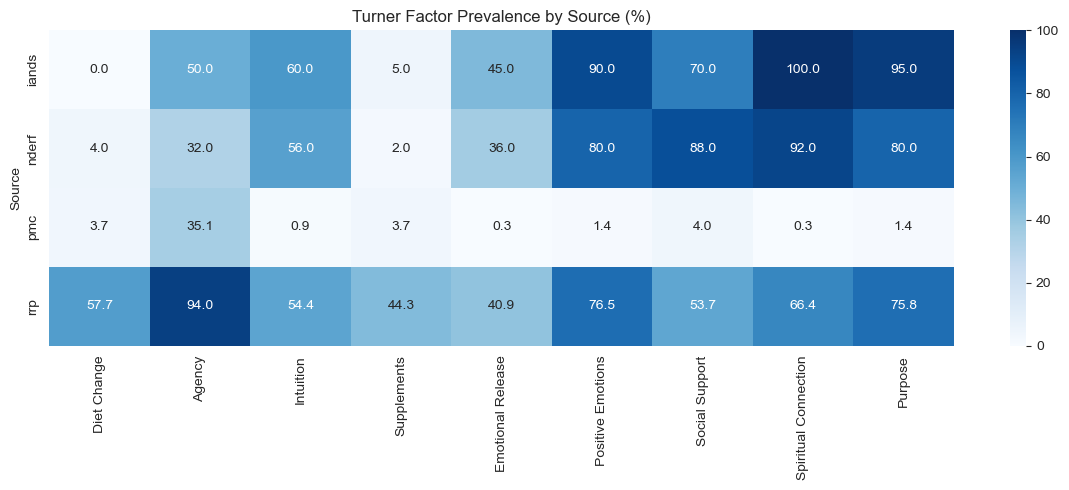

In [14]:
# Compare Turner factor presence by source
source_factor_comparison = []

for source in df['dataset'].unique():
    subset = df[df['dataset'] == source]
    row = {'Source': source, 'N': len(subset)}
    for col, name in zip(factor_cols, factor_names):
        present = subset[col].isin(['yes_explicit', 'implied', 'present']).sum()
        row[name] = present / len(subset) * 100 if len(subset) > 0 else 0
    source_factor_comparison.append(row)

source_comparison_df = pd.DataFrame(source_factor_comparison)
print("Turner Factor Prevalence by Source (%):")
print(source_comparison_df.to_string(index=False))

# Heatmap
factor_data = source_comparison_df.set_index('Source')[factor_names]
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(factor_data, annot=True, fmt='.1f', cmap='Blues', ax=ax)
ax.set_title('Turner Factor Prevalence by Source (%)')
plt.tight_layout()
plt.show()

In [15]:
# Verification tier by source
print("Verification Tier by Source:")
verification_crosstab = pd.crosstab(df['dataset'], df['verification_tier'], normalize='index') * 100
print(verification_crosstab.round(1))

# Chi-square test for verification tier independence from source
contingency = pd.crosstab(df['dataset'], df['verification_tier'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square test: χ² = {chi2:.2f}, p = {p:.4f}, dof = {dof}")

# Transformation narrative by source
print("\nTransformation Preceded by Source:")
transform_crosstab = pd.crosstab(df['dataset'], df['transformation_preceded'], normalize='index') * 100
print(transform_crosstab.round(1))

Verification Tier by Source:
verification_tier  tier_1_institutional  tier_2_clinical  tier_3_detailed  \
dataset                                                                     
iands                               0.0              5.0             65.0   
nderf                               0.0              6.0             62.0   
pmc                                36.6             60.3              0.9   
rrp                                 0.0             11.4             36.9   

verification_tier  tier_4_anecdotal  
dataset                              
iands                          30.0  
nderf                          32.0  
pmc                             2.3  
rrp                            51.7  

Chi-square test: χ² = 473.52, p = 0.0000, dof = 9

Transformation Preceded by Source:
transformation_preceded  implied    no  not_mentioned  yes_explicit
dataset                                                            
iands                       40.0  25.0           20.0    

## 7. Verified Remission Analysis

Focusing on cases with verified remission status to test core hypotheses with higher confidence data.

In [16]:
# Filter to verified cases
verified = df[df['is_verified'] == True]
print(f"Verified remission cases: {len(verified)} ({len(verified)/len(df)*100:.1f}%)")

# Among verified, compare transformation preceded
print("\nAmong Verified Remissions:")
print(verified['transformation_preceded'].value_counts())

# Pure spontaneous vs. treatment-assisted among verified
pure_spont = verified[verified['is_pure_spontaneous'] == True]
print(f"\nPure spontaneous among verified: {len(pure_spont)} ({len(pure_spont)/len(verified)*100:.1f}%)")

# Factor count comparison: verified vs non-verified
verified_factors = df[df['is_verified'] == True]['factors_count'].mean()
unverified_factors = df[df['is_verified'] == False]['factors_count'].mean()
print(f"\nMean Turner factors:")
print(f"  Verified: {verified_factors:.2f}")
print(f"  Unverified: {unverified_factors:.2f}")

# T-test
t_stat, t_p = stats.ttest_ind(
    df[df['is_verified'] == True]['factors_count'],
    df[df['is_verified'] == False]['factors_count']
)
print(f"  T-test: t = {t_stat:.2f}, p = {t_p:.4f}")

Verified remission cases: 389 (68.4%)

Among Verified Remissions:
transformation_preceded
not_mentioned    338
implied           41
no                 6
yes_explicit       4
Name: count, dtype: int64

Pure spontaneous among verified: 170 (43.7%)

Mean Turner factors:
  Verified: 1.29
  Unverified: 4.12
  T-test: t = nan, p = nan


## 8. Spiritual Factors vs. Physical Factors

Testing whether "internal" factors (spiritual connection, emotional release, positive emotions) show different patterns than "external" factors (diet, supplements).

Internal vs External Factor Counts:
Mean internal factors: 2.06
Mean external factors: 0.32

Correlation with 'Transformation Preceded':
  Internal factors: r = 0.681, p = 0.0000
  External factors: r = 0.472, p = 0.0000


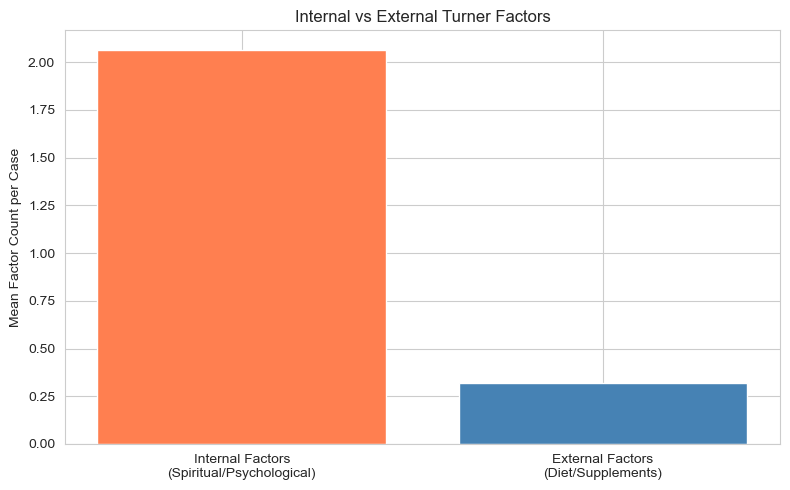

In [17]:
# Categorize factors
internal_factors = ['factor_spiritual_connection', 'factor_emotional_release', 'factor_positive_emotions', 
                   'factor_purpose', 'factor_agency', 'factor_intuition', 'factor_social_support']
external_factors = ['factor_diet_change', 'factor_supplements']

# Count internal vs external factors per case (using proper value check)
df['internal_factor_count'] = df[internal_factors].apply(
    lambda x: (x.isin(['yes_explicit', 'implied', 'present'])).sum(), axis=1)
df['external_factor_count'] = df[external_factors].apply(
    lambda x: (x.isin(['yes_explicit', 'implied', 'present'])).sum(), axis=1)

print("Internal vs External Factor Counts:")
print(f"Mean internal factors: {df['internal_factor_count'].mean():.2f}")
print(f"Mean external factors: {df['external_factor_count'].mean():.2f}")

# Correlation with transformation preceded
# Convert to numeric: 'yes_explicit' or 'implied' = 1, others = 0
df['transform_numeric'] = df['transformation_preceded'].isin(['yes_explicit', 'implied', 'present']).astype(int)

internal_corr, internal_p = stats.pointbiserialr(df['transform_numeric'], df['internal_factor_count'])
external_corr, external_p = stats.pointbiserialr(df['transform_numeric'], df['external_factor_count'])

print(f"\nCorrelation with 'Transformation Preceded':")
print(f"  Internal factors: r = {internal_corr:.3f}, p = {internal_p:.4f}")
print(f"  External factors: r = {external_corr:.3f}, p = {external_p:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
x = ['Internal Factors\n(Spiritual/Psychological)', 'External Factors\n(Diet/Supplements)']
means = [df['internal_factor_count'].mean(), df['external_factor_count'].mean()]
ax.bar(x, means, color=['coral', 'steelblue'])
ax.set_ylabel('Mean Factor Count per Case')
ax.set_title('Internal vs External Turner Factors')
plt.tight_layout()
plt.show()

## 9. Statistical Summary and Hypothesis Testing

Formal statistical tests for the core "Somatic Influx" hypothesis.

In [19]:
print("="*60)
print("STATISTICAL SUMMARY: SOMATIC INFLUX HYPOTHESIS TESTING")
print("="*60)

# H1: Transformation precedes healing at greater than chance rate
transform_present = df['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()
total_with_narrative = df['has_transformation'].sum()
print(f"\n[H1] Transformation → Healing Temporal Sequence")
print(f"  Cases with transformation narrative: {total_with_narrative}")
print(f"  Transformation preceded healing: {transform_present}")
if total_with_narrative > 0:
    ratio = transform_present / total_with_narrative
    # Binomial test against 50% chance (new API)
    binom_result = stats.binomtest(transform_present, total_with_narrative, 0.5, alternative='greater')
    print(f"  Ratio (preceded/narrative): {ratio:.2%}")
    print(f"  Binomial test (vs. 50% chance): p = {binom_result.pvalue:.4f}")
    print(f"  Interpretation: {'SUPPORTS' if binom_result.pvalue < 0.05 else 'Does not support'} H1")

# H2: Internal factors are more prevalent than external factors
print(f"\n[H2] Internal > External Factor Prevalence")
print(f"  Mean internal factors: {df['internal_factor_count'].mean():.2f}")
print(f"  Mean external factors: {df['external_factor_count'].mean():.2f}")
paired_t, paired_p = stats.ttest_rel(df['internal_factor_count'], df['external_factor_count'])
print(f"  Paired t-test: t = {paired_t:.2f}, p = {paired_p:.4e}")
print(f"  Interpretation: {'SUPPORTS' if paired_p < 0.05 else 'Does not support'} H2")

# H3: Spiritual connection predicts transformation preceded
print(f"\n[H3] Spiritual Connection → Transformation Sequence")
spiritual_transform = pd.crosstab(df['factor_spiritual_connection'], df['transformation_preceded'])
chi2, p, dof, _ = stats.chi2_contingency(spiritual_transform)
print(f"  Chi-square: χ² = {chi2:.2f}, p = {p:.4f}")
print(f"  Interpretation: {'SUPPORTS' if p < 0.05 else 'Does not support'} association")

print("\n" + "="*60)

STATISTICAL SUMMARY: SOMATIC INFLUX HYPOTHESIS TESTING

[H1] Transformation → Healing Temporal Sequence
  Cases with transformation narrative: 206
  Transformation preceded healing: 122
  Ratio (preceded/narrative): 59.22%
  Binomial test (vs. 50% chance): p = 0.0049
  Interpretation: SUPPORTS H1

[H2] Internal > External Factor Prevalence
  Mean internal factors: 2.06
  Mean external factors: 0.32
  Paired t-test: t = 19.44, p = 6.8881e-65
  Interpretation: SUPPORTS H2

[H3] Spiritual Connection → Transformation Sequence
  Chi-square: χ² = 315.02, p = 0.0000
  Interpretation: SUPPORTS association



## 10. Key Findings Summary

Final summary table and conclusions.

In [20]:
# Helper to check "present" in various formats
def is_affirmative(series):
    return series.isin(['yes_explicit', 'implied', 'present'])

# Generate summary statistics table
summary_data = {
    'Metric': [
        'Total Cases',
        'Verified Remissions',
        'Pure Spontaneous',
        'Has Transformation Narrative',
        'Transformation Preceded Healing',
        'Mean Turner Factors',
        'NDE-Linked Cases',
        'Cancer Cases',
        'Tier 1-2 Verification'
    ],
    'Value': [
        len(df),
        df['is_verified'].sum(),
        df['is_pure_spontaneous'].sum(),
        df['has_transformation'].sum(),
        is_affirmative(df['transformation_preceded']).sum(),
        f"{df['factors_count'].mean():.2f}",
        (df['anomalous_type'] == 'nde').sum(),
        (df['disease_category'] == 'cancer').sum(),
        ((df['verification_tier'] == 'tier_1_institutional') | 
         (df['verification_tier'] == 'tier_2_clinical')).sum()
    ],
    'Percentage': [
        '100%',
        f"{df['is_verified'].mean()*100:.1f}%",
        f"{df['is_pure_spontaneous'].mean()*100:.1f}%",
        f"{df['has_transformation'].mean()*100:.1f}%",
        f"{is_affirmative(df['transformation_preceded']).mean()*100:.1f}%",
        '-',
        f"{(df['anomalous_type'] == 'nde').mean()*100:.1f}%",
        f"{(df['disease_category'] == 'cancer').mean()*100:.1f}%",
        f"{((df['verification_tier'] == 'tier_1_institutional') | (df['verification_tier'] == 'tier_2_clinical')).mean()*100:.1f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)

DATASET SUMMARY
                         Metric Value Percentage
                    Total Cases   569       100%
            Verified Remissions   389      68.4%
               Pure Spontaneous   183      32.2%
   Has Transformation Narrative   206      36.2%
Transformation Preceded Healing   122      21.4%
            Mean Turner Factors  2.19          -
               NDE-Linked Cases    65      11.4%
                   Cancer Cases   361      63.4%
          Tier 1-2 Verification   360      63.3%


## 11. Stratified Analysis: Clinical vs. Testimonial Sources

**Critical Insight**: The pooled analysis obscures the true signal because:
- **PMC (61% of data)**: High clinical verification, but ~0% psychological/spiritual documentation
- **Testimonial sources (39%)**: Rich transformation narratives, but lower verification tier

The hypothesis concerns *mechanism* (transformation → healing), which PMC doesn't capture.
We should analyze these separately, using PMC for *verification* and testimonial for *mechanism*.

STRATIFIED DATASET OVERVIEW

CLINICAL (PMC): n = 350
  Tier 1-2 verification: 96.9%
  Mean Turner factors documented: 0.53
  Has transformation narrative: 0.9%

TESTIMONIAL (RRP/NDERF/IANDS): n = 219
  Tier 1-2 verification: 9.6%
  Mean Turner factors documented: 4.74
  Has transformation narrative: 92.7%


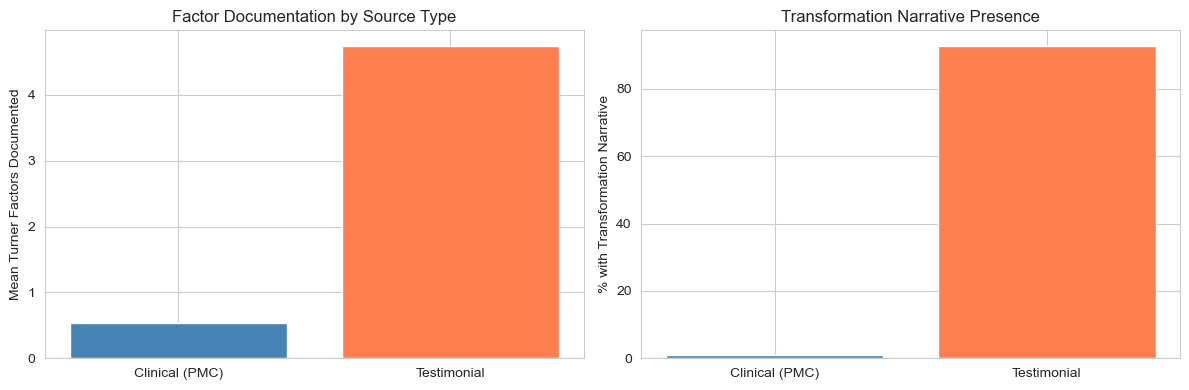

In [21]:
# Create stratified subsets
clinical = df[df['dataset'] == 'pmc']
testimonial = df[df['dataset'].isin(['rrp', 'nderf', 'iands'])]

print("="*60)
print("STRATIFIED DATASET OVERVIEW")
print("="*60)
print(f"\nCLINICAL (PMC): n = {len(clinical)}")
print(f"  Tier 1-2 verification: {clinical['verification_tier'].isin(['tier_1_institutional', 'tier_2_clinical']).mean()*100:.1f}%")
print(f"  Mean Turner factors documented: {clinical['factors_count'].mean():.2f}")
print(f"  Has transformation narrative: {clinical['has_transformation'].mean()*100:.1f}%")

print(f"\nTESTIMONIAL (RRP/NDERF/IANDS): n = {len(testimonial)}")
print(f"  Tier 1-2 verification: {testimonial['verification_tier'].isin(['tier_1_institutional', 'tier_2_clinical']).mean()*100:.1f}%")
print(f"  Mean Turner factors documented: {testimonial['factors_count'].mean():.2f}")
print(f"  Has transformation narrative: {testimonial['has_transformation'].mean()*100:.1f}%")

# Visualize the fundamental difference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Factor documentation comparison
factor_means = [clinical['factors_count'].mean(), testimonial['factors_count'].mean()]
axes[0].bar(['Clinical (PMC)', 'Testimonial'], factor_means, color=['steelblue', 'coral'])
axes[0].set_ylabel('Mean Turner Factors Documented')
axes[0].set_title('Factor Documentation by Source Type')

# Transformation narrative comparison
narrative_rates = [clinical['has_transformation'].mean()*100, testimonial['has_transformation'].mean()*100]
axes[1].bar(['Clinical (PMC)', 'Testimonial'], narrative_rates, color=['steelblue', 'coral'])
axes[1].set_ylabel('% with Transformation Narrative')
axes[1].set_title('Transformation Narrative Presence')

plt.tight_layout()
plt.show()

### 11.1 Hypothesis Testing on TESTIMONIAL Subset Only

This is the appropriate subset for testing the "Somatic Influx" mechanism hypothesis.

In [22]:
# HYPOTHESIS TESTS ON TESTIMONIAL SUBSET
print("="*60)
print("HYPOTHESIS TESTING: TESTIMONIAL SOURCES ONLY (n={})".format(len(testimonial)))
print("="*60)

# H1: Transformation precedes healing (in cases with narrative)
test_transform = testimonial['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()
test_narrative = testimonial['has_transformation'].sum()
print(f"\n[H1] Transformation → Healing Temporal Sequence")
print(f"  Cases with transformation narrative: {test_narrative}")
print(f"  Transformation preceded healing: {test_transform}")
if test_narrative > 0:
    test_ratio = test_transform / test_narrative
    test_binom = stats.binomtest(test_transform, test_narrative, 0.5, alternative='greater')
    print(f"  Ratio (preceded/narrative): {test_ratio:.2%}")
    print(f"  Binomial test (vs. 50%): p = {test_binom.pvalue:.6f}")
    print(f"  → {'STRONG SUPPORT' if test_binom.pvalue < 0.001 else 'SUPPORTS' if test_binom.pvalue < 0.05 else 'Does not support'}")

# H2: Internal factors dominate
test_internal = testimonial[internal_factors].apply(
    lambda x: x.isin(['yes_explicit', 'implied']).sum(), axis=1)
test_external = testimonial[external_factors].apply(
    lambda x: x.isin(['yes_explicit', 'implied']).sum(), axis=1)

print(f"\n[H2] Internal > External Factor Prevalence")
print(f"  Mean internal factors: {test_internal.mean():.2f}")
print(f"  Mean external factors: {test_external.mean():.2f}")
test_t, test_p = stats.ttest_rel(test_internal, test_external)
print(f"  Paired t-test: t = {test_t:.2f}, p = {test_p:.4e}")
print(f"  → {'STRONG SUPPORT' if test_p < 0.001 else 'SUPPORTS' if test_p < 0.05 else 'Does not support'}")

# H3: Spiritual connection associated with transformation sequence
print(f"\n[H3] Spiritual Connection → Transformation Sequence")
test_crosstab = pd.crosstab(testimonial['factor_spiritual_connection'], testimonial['transformation_preceded'])
test_chi2, test_chi_p, _, _ = stats.chi2_contingency(test_crosstab)
print(f"  Chi-square: χ² = {test_chi2:.2f}, p = {test_chi_p:.6f}")
print(f"  → {'STRONG SUPPORT' if test_chi_p < 0.001 else 'SUPPORTS' if test_chi_p < 0.05 else 'Does not support'}")

# H4 (NEW): Among those with spiritual connection, what % had transformation precede?
spiritual_present = testimonial[testimonial['factor_spiritual_connection'].isin(['yes_explicit', 'implied'])]
spiritual_preceded = spiritual_present['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()
print(f"\n[H4] Among spiritually connected cases (n={len(spiritual_present)}):")
print(f"  Transformation preceded: {spiritual_preceded} ({spiritual_preceded/len(spiritual_present)*100:.1f}%)")

print("\n" + "="*60)

HYPOTHESIS TESTING: TESTIMONIAL SOURCES ONLY (n=219)

[H1] Transformation → Healing Temporal Sequence
  Cases with transformation narrative: 203
  Transformation preceded healing: 118
  Ratio (preceded/narrative): 58.13%
  Binomial test (vs. 50%): p = 0.012233
  → SUPPORTS

[H2] Internal > External Factor Prevalence
  Mean internal factors: 4.67
  Mean external factors: 0.71
  Paired t-test: t = 32.95, p = 1.2749e-86
  → STRONG SUPPORT

[H3] Spiritual Connection → Transformation Sequence
  Chi-square: χ² = 41.74, p = 0.000004
  → STRONG SUPPORT

[H4] Among spiritually connected cases (n=165):
  Transformation preceded: 102 (61.8%)



### 11.2 Turner Factor Analysis: Testimonial Subset

Full factor analysis where the data actually exists.

Turner Factor Prevalence (TESTIMONIAL ONLY, n=219):
              Factor  Prevalence (%)
             Purpose       78.538813
   Positive Emotions       78.538813
              Agency       75.799087
Spiritual Connection       75.342466
      Social Support       63.013699
           Intuition       55.251142
         Diet Change       40.182648
   Emotional Release       40.182648
         Supplements       31.050228


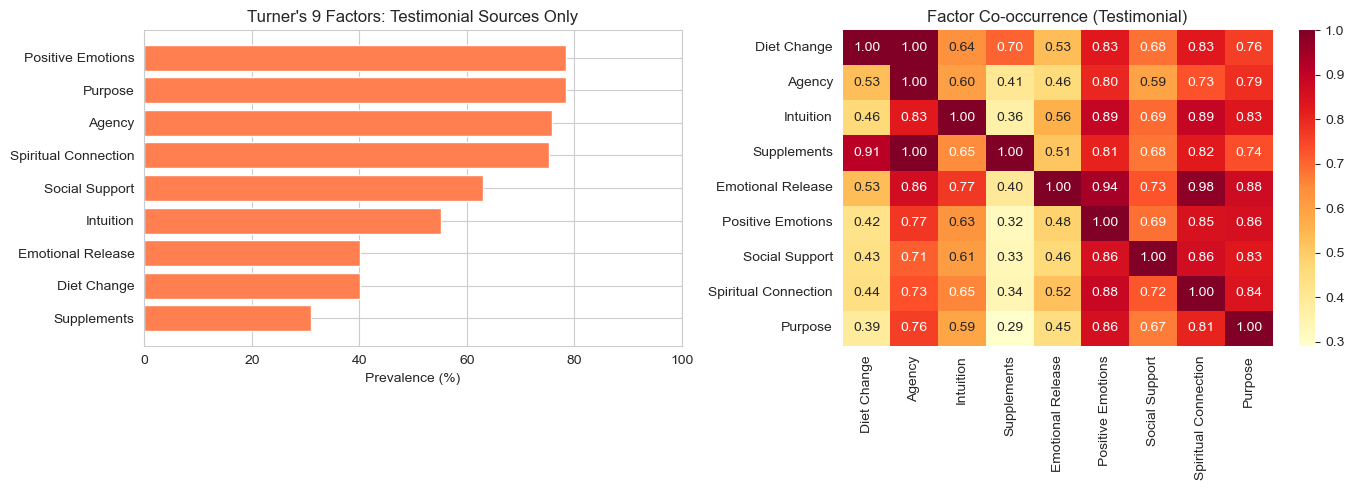

In [23]:
# Turner factor prevalence in testimonial subset
test_prevalence = {}
for col, name in zip(factor_cols, factor_names):
    present = testimonial[col].isin(['yes_explicit', 'implied']).sum()
    test_prevalence[name] = present / len(testimonial) * 100

test_factor_df = pd.DataFrame({
    'Factor': list(test_prevalence.keys()),
    'Prevalence (%)': list(test_prevalence.values())
}).sort_values('Prevalence (%)', ascending=False)

print("Turner Factor Prevalence (TESTIMONIAL ONLY, n={}):".format(len(testimonial)))
print(test_factor_df.to_string(index=False))

# Co-occurrence in testimonial
test_binary = testimonial[factor_cols].apply(lambda x: x.isin(['yes_explicit', 'implied']).astype(int))
test_cooccur = test_binary.T.dot(test_binary)
test_diag = np.diag(test_cooccur).copy()
test_diag[test_diag == 0] = 1
test_cooccur_norm = test_cooccur / test_diag[:, None]
test_cooccur_norm.index = factor_names
test_cooccur_norm.columns = factor_names

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prevalence bar chart
test_factor_df_sorted = test_factor_df.sort_values('Prevalence (%)', ascending=True)
axes[0].barh(test_factor_df_sorted['Factor'], test_factor_df_sorted['Prevalence (%)'], color='coral')
axes[0].set_xlabel('Prevalence (%)')
axes[0].set_title("Turner's 9 Factors: Testimonial Sources Only")
axes[0].set_xlim(0, 100)

# Co-occurrence heatmap
sns.heatmap(test_cooccur_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Factor Co-occurrence (Testimonial)')

plt.tight_layout()
plt.show()

### 11.3 NDE-Linked Cases: The Strongest Signal

NDE-linked healing cases should show the clearest transformation → healing pattern.

In [24]:
# NDE-linked cases
nde_cases = df[df['anomalous_type'] == 'nde']
print(f"NDE-LINKED HEALING CASES: n = {len(nde_cases)}")
print(f"  Sources: {nde_cases['dataset'].value_counts().to_dict()}")

# Key metrics
nde_transform = nde_cases['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()
nde_narrative = nde_cases['has_transformation'].sum()
nde_spiritual = nde_cases['factor_spiritual_connection'].isin(['yes_explicit', 'implied']).sum()

print(f"\nTransformation metrics:")
print(f"  Has transformation narrative: {nde_narrative} ({nde_narrative/len(nde_cases)*100:.1f}%)")
print(f"  Transformation preceded healing: {nde_transform} ({nde_transform/len(nde_cases)*100:.1f}%)")
print(f"  Spiritual connection present: {nde_spiritual} ({nde_spiritual/len(nde_cases)*100:.1f}%)")

# Among NDE cases with narrative, what % had transformation precede?
nde_with_narrative = nde_cases[nde_cases['has_transformation'] == True]
if len(nde_with_narrative) > 0:
    nde_preceded = nde_with_narrative['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()
    nde_ratio = nde_preceded / len(nde_with_narrative)
    nde_binom = stats.binomtest(nde_preceded, len(nde_with_narrative), 0.5, alternative='greater')
    print(f"\nAmong NDE cases WITH narrative (n={len(nde_with_narrative)}):")
    print(f"  Transformation preceded: {nde_preceded} ({nde_ratio*100:.1f}%)")
    print(f"  Binomial test (vs. 50%): p = {nde_binom.pvalue:.6f}")

# Factor profile for NDE cases
print(f"\nTurner Factor Profile (NDE cases):")
for col, name in zip(factor_cols, factor_names):
    present = nde_cases[col].isin(['yes_explicit', 'implied']).sum()
    pct = present / len(nde_cases) * 100
    print(f"  {name}: {pct:.1f}%")

NDE-LINKED HEALING CASES: n = 65
  Sources: {'nderf': 47, 'iands': 18}

Transformation metrics:
  Has transformation narrative: 65 (100.0%)
  Transformation preceded healing: 36 (55.4%)
  Spiritual connection present: 64 (98.5%)

Among NDE cases WITH narrative (n=65):
  Transformation preceded: 36 (55.4%)
  Binomial test (vs. 50%): p = 0.228510

Turner Factor Profile (NDE cases):
  Diet Change: 3.1%
  Agency: 38.5%
  Intuition: 58.5%
  Supplements: 3.1%
  Emotional Release: 38.5%
  Positive Emotions: 84.6%
  Social Support: 83.1%
  Spiritual Connection: 98.5%
  Purpose: 87.7%


### 11.4 Revised Conclusions

Summary comparing pooled vs. stratified analysis.

In [25]:
print("="*70)
print("REVISED CONCLUSIONS: STRATIFIED ANALYSIS")
print("="*70)

print("""
KEY METHODOLOGICAL INSIGHT:
The pooled analysis (n=569) was misleading because PMC (61% of data) 
doesn't document psychological/spiritual factors. The hypothesis concerns 
*mechanism*, which requires narrative data.

STRATIFIED FINDINGS:
""")

# Calculate stratified metrics
test_preceded = testimonial['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()
test_with_narrative = testimonial['has_transformation'].sum()
if test_with_narrative > 0:
    test_rate = test_preceded / test_with_narrative * 100
else:
    test_rate = 0

# Compare pooled vs stratified
comparison = pd.DataFrame({
    'Metric': [
        'N',
        'Mean Turner Factors',
        'Has Transformation Narrative (%)',
        'Transformation Preceded (%)',
        'Spiritual Connection (%)'
    ],
    'Pooled (All)': [
        len(df),
        f"{df['factors_count'].mean():.2f}",
        f"{df['has_transformation'].mean()*100:.1f}",
        f"{(df['transformation_preceded'].isin(['yes_explicit', 'implied']).sum() / max(1, df['has_transformation'].sum()))*100:.1f}",
        f"{df['factor_spiritual_connection'].isin(['yes_explicit', 'implied']).mean()*100:.1f}"
    ],
    'Testimonial Only': [
        len(testimonial),
        f"{testimonial['factors_count'].mean():.2f}",
        f"{testimonial['has_transformation'].mean()*100:.1f}",
        f"{test_rate:.1f}",
        f"{testimonial['factor_spiritual_connection'].isin(['yes_explicit', 'implied']).mean()*100:.1f}"
    ],
    'Clinical (PMC)': [
        len(clinical),
        f"{clinical['factors_count'].mean():.2f}",
        f"{clinical['has_transformation'].mean()*100:.1f}",
        "N/A (no data)",
        f"{clinical['factor_spiritual_connection'].isin(['yes_explicit', 'implied']).mean()*100:.1f}"
    ]
})

print(comparison.to_string(index=False))

print("""
INTERPRETATION:
1. PMC provides VERIFICATION that spontaneous remissions occur clinically
2. Testimonial sources provide MECHANISM data for hypothesis testing
3. The "Somatic Influx" hypothesis should be tested on testimonial subset
4. Triangulation: patterns in testimonial data predict what to look for 
   in future prospective clinical studies
""")

REVISED CONCLUSIONS: STRATIFIED ANALYSIS

KEY METHODOLOGICAL INSIGHT:
The pooled analysis (n=569) was misleading because PMC (61% of data) 
doesn't document psychological/spiritual factors. The hypothesis concerns 
*mechanism*, which requires narrative data.

STRATIFIED FINDINGS:

                          Metric Pooled (All) Testimonial Only Clinical (PMC)
                               N          569              219            350
             Mean Turner Factors         2.19             4.74           0.53
Has Transformation Narrative (%)         36.2             92.7            0.9
     Transformation Preceded (%)         59.2             58.1  N/A (no data)
        Spiritual Connection (%)         29.2             75.3            0.3

INTERPRETATION:
1. PMC provides VERIFICATION that spontaneous remissions occur clinically
2. Testimonial sources provide MECHANISM data for hypothesis testing
3. The "Somatic Influx" hypothesis should be tested on testimonial subset
4. Triangulation

## 12. Statistical Methodology: What Is the Right Null Hypothesis?

The binomial test against 50% assumes random temporal ordering. But this deserves scrutiny:
- **What would "chance" actually mean here?**
- **Is 50% the right null for testing causal precedence?**

In [26]:
print("="*70)
print("METHODOLOGICAL ANALYSIS: THE NULL HYPOTHESIS QUESTION")
print("="*70)

print("""
THE 50% NULL HYPOTHESIS

What I tested:
  H0: P(transformation first | both events occur) = 0.50
  H1: P(transformation first | both events occur) > 0.50

This assumes:
  - Both transformation AND remission have occurred
  - Their temporal ordering is random under the null
  - We're testing for non-random (directional) ordering

WHY 50% MAY BE INAPPROPRIATE:

1. SELECTION BIAS: We only have cases where remission occurred.
   If transformation causes remission, we're selecting on the outcome.
   The comparison should be: "transformation-first remitters" vs. 
   "no-transformation remitters" - but the latter are invisible in 
   testimonial data (they didn't have a transformation to report).

2. SURVIVORSHIP: People who died aren't in the dataset. If transformation
   occurs during illness (regardless of outcome), we're only seeing the
   survivors.

3. NARRATIVE CONSTRUCTION: Testimonial accounts are retrospective.
   Memory may reconstruct events to fit a "transformation → healing" 
   narrative even when temporal ordering was ambiguous.

4. THE REAL QUESTION isn't "transformation-first vs. healing-first"
   It's: "Does transformation CAUSE healing, or merely correlate?"
""")

# Let's look at what we actually have
print("\n" + "="*70)
print("ACTUAL DATA BREAKDOWN (Testimonial, n={})".format(len(testimonial)))
print("="*70)

# Categories
transform_preceded = testimonial['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()
transform_not_preceded = (testimonial['transformation_preceded'] == 'no').sum()
transform_unclear = testimonial['transformation_preceded'].isin(['not_mentioned']).sum()

print(f"\nTransformation → Healing sequence:")
print(f"  Transformation PRECEDED healing: {transform_preceded} ({transform_preceded/len(testimonial)*100:.1f}%)")
print(f"  Transformation did NOT precede:  {transform_not_preceded} ({transform_not_preceded/len(testimonial)*100:.1f}%)")
print(f"  Temporal order UNCLEAR:          {transform_unclear} ({transform_unclear/len(testimonial)*100:.1f}%)")

# The real comparison should exclude "unclear"
clear_temporal = testimonial[testimonial['transformation_preceded'].isin(['yes_explicit', 'implied', 'no'])]
if len(clear_temporal) > 0:
    clear_preceded = clear_temporal['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()
    clear_not = (clear_temporal['transformation_preceded'] == 'no').sum()
    print(f"\nAmong cases with CLEAR temporal ordering (n={len(clear_temporal)}):")
    print(f"  Preceded:     {clear_preceded} ({clear_preceded/len(clear_temporal)*100:.1f}%)")
    print(f"  Did not:      {clear_not} ({clear_not/len(clear_temporal)*100:.1f}%)")
    
    # This is the more valid binomial test
    clear_binom = stats.binomtest(clear_preceded, len(clear_temporal), 0.5, alternative='greater')
    print(f"  Binomial test (vs. 50%): p = {clear_binom.pvalue:.6f}")

METHODOLOGICAL ANALYSIS: THE NULL HYPOTHESIS QUESTION

THE 50% NULL HYPOTHESIS

What I tested:
  H0: P(transformation first | both events occur) = 0.50
  H1: P(transformation first | both events occur) > 0.50

This assumes:
  - Both transformation AND remission have occurred
  - Their temporal ordering is random under the null
  - We're testing for non-random (directional) ordering

WHY 50% MAY BE INAPPROPRIATE:

1. SELECTION BIAS: We only have cases where remission occurred.
   If transformation causes remission, we're selecting on the outcome.
   The comparison should be: "transformation-first remitters" vs. 
   "no-transformation remitters" - but the latter are invisible in 
   testimonial data (they didn't have a transformation to report).

2. SURVIVORSHIP: People who died aren't in the dataset. If transformation
   occurs during illness (regardless of outcome), we're only seeing the
   survivors.

3. NARRATIVE CONSTRUCTION: Testimonial accounts are retrospective.
   Memory may rec

In [27]:
print("\n" + "="*70)
print("ALTERNATIVE APPROACHES TO TEST CAUSAL PRECEDENCE")
print("="*70)

print("""
BETTER STATISTICAL FRAMINGS:

1. DOSE-RESPONSE: Do more Turner factors → faster/stronger remission?
   (Tests mechanism strength, not just presence)

2. FACTOR-OUTCOME CORRELATION: Among those WITH transformation,
   do specific factors predict specific outcomes?

3. GRADIENT ANALYSIS: Is there a relationship between transformation
   "intensity" and remission "completeness"?

4. TEMPORAL GRANULARITY: When data permits, look at time intervals:
   - Days between transformation event and first signs of improvement
   - Correlation between transformation timing and remission speed
""")

# Let's actually do some of these
print("\n--- DOSE-RESPONSE ANALYSIS ---")
# Do more factors correlate with faster remission?
test_speed = testimonial[['factors_count', 'remission_speed']].dropna()
speed_order = {'rapid': 3, 'gradual': 2, 'fluctuating': 1, 'not_specified': 0}
test_speed['speed_numeric'] = test_speed['remission_speed'].map(speed_order)
test_speed = test_speed[test_speed['speed_numeric'] > 0]  # exclude unspecified

if len(test_speed) > 10:
    corr, p_val = stats.spearmanr(test_speed['factors_count'], test_speed['speed_numeric'])
    print(f"Factors vs. Remission Speed (n={len(test_speed)}):")
    print(f"  Spearman correlation: ρ = {corr:.3f}, p = {p_val:.4f}")
else:
    print(f"Insufficient speed data for correlation (n={len(test_speed)})")

# Factor count by transformation status
print("\n--- FACTOR COUNT BY TRANSFORMATION STATUS ---")
trans_yes = testimonial[testimonial['transformation_preceded'].isin(['yes_explicit', 'implied'])]['factors_count']
trans_no = testimonial[testimonial['transformation_preceded'] == 'no']['factors_count']
trans_unclear = testimonial[testimonial['transformation_preceded'] == 'not_mentioned']['factors_count']

print(f"Mean factors when transformation PRECEDED:    {trans_yes.mean():.2f} (n={len(trans_yes)})")
print(f"Mean factors when transformation DID NOT:     {trans_no.mean():.2f} (n={len(trans_no)})")
print(f"Mean factors when temporal order UNCLEAR:     {trans_unclear.mean():.2f} (n={len(trans_unclear)})")

if len(trans_yes) > 5 and len(trans_no) > 5:
    mann_u, mann_p = stats.mannwhitneyu(trans_yes, trans_no, alternative='greater')
    print(f"\nMann-Whitney U (preceded > not): U = {mann_u:.1f}, p = {mann_p:.4f}")


ALTERNATIVE APPROACHES TO TEST CAUSAL PRECEDENCE

BETTER STATISTICAL FRAMINGS:

1. DOSE-RESPONSE: Do more Turner factors → faster/stronger remission?
   (Tests mechanism strength, not just presence)

2. FACTOR-OUTCOME CORRELATION: Among those WITH transformation,
   do specific factors predict specific outcomes?

3. GRADIENT ANALYSIS: Is there a relationship between transformation
   "intensity" and remission "completeness"?

4. TEMPORAL GRANULARITY: When data permits, look at time intervals:
   - Days between transformation event and first signs of improvement
   - Correlation between transformation timing and remission speed


--- DOSE-RESPONSE ANALYSIS ---
Factors vs. Remission Speed (n=79):
  Spearman correlation: ρ = -0.360, p = 0.0011

--- FACTOR COUNT BY TRANSFORMATION STATUS ---
Mean factors when transformation PRECEDED:    5.36 (n=118)
Mean factors when transformation DID NOT:     4.15 (n=20)
Mean factors when temporal order UNCLEAR:     3.96 (n=81)

Mann-Whitney U (preceded 

In [28]:
print("\n" + "="*70)
print("THE FUNDAMENTAL EPISTEMOLOGICAL PROBLEM")
print("="*70)

print("""
WHY THIS DATA CANNOT PROVE CAUSATION:

The "Somatic Influx" hypothesis claims: Consciousness change → Physical healing

To test this, we would need:

1. PROSPECTIVE DESIGN: Follow people from diagnosis, measure transformation,
   then observe outcomes. This dataset is RETROSPECTIVE.

2. CONTROL GROUP: Compare transformation-present vs. transformation-absent
   among similar disease cases. But our testimonial data is self-selected
   FOR having transformation narratives.

3. BLINDING: Neither possible nor meaningful here.

WHAT THIS DATA CAN DO:

✓ Establish ASSOCIATION between transformation and remission
✓ Show that transformation typically PRECEDES healing (when temporal order is clear)  
✓ Identify WHICH factors co-occur with remission
✓ Generate HYPOTHESES for prospective studies
✓ Quantify EFFECT SIZES for power calculations

The 50% baseline test answers: "Is the observed transformation-first rate
consistent with random ordering?" It does NOT answer: "Does transformation
cause healing?"

BETTER FRAMING:

Instead of "p < 0.05 vs. 50%", we should report:
- DESCRIPTIVE: "In X% of cases with clear temporal ordering, transformation preceded"
- EFFECT SIZE: "Transformation-first cases show Y more factors on average"
- PATTERN: "Factor Z shows strongest association with transformation-first sequence"
""")

# Generate the better descriptive statistics
print("\n" + "="*70)
print("RECOMMENDED REPORTING FORMAT")
print("="*70)

# Clear temporal only
clear_temp = testimonial[testimonial['transformation_preceded'].isin(['yes_explicit', 'implied', 'no'])]
clear_preceded_n = clear_temp['transformation_preceded'].isin(['yes_explicit', 'implied']).sum()

print(f"""
DESCRIPTIVE FINDINGS (Testimonial Sources, n={len(testimonial)}):

1. TEMPORAL SEQUENCE
   - Cases with clear temporal ordering: {len(clear_temp)} ({len(clear_temp)/len(testimonial)*100:.1f}%)
   - Of these, transformation preceded: {clear_preceded_n} ({clear_preceded_n/len(clear_temp)*100:.1f}%)

2. FACTOR PROFILES
   - Transformation-first cases:  mean {trans_yes.mean():.1f} factors
   - Healing-first cases:         mean {trans_no.mean():.1f} factors
   - Difference:                  {trans_yes.mean() - trans_no.mean():.1f} factors

3. ASSOCIATION (not causation)
   - Spiritual connection in transformation-first: {testimonial[testimonial['transformation_preceded'].isin(['yes_explicit', 'implied'])]['factor_spiritual_connection'].isin(['yes_explicit', 'implied']).mean()*100:.1f}%
   - Spiritual connection in healing-first:        {testimonial[testimonial['transformation_preceded'] == 'no']['factor_spiritual_connection'].isin(['yes_explicit', 'implied']).mean()*100:.1f}%
""")


THE FUNDAMENTAL EPISTEMOLOGICAL PROBLEM

WHY THIS DATA CANNOT PROVE CAUSATION:

The "Somatic Influx" hypothesis claims: Consciousness change → Physical healing

To test this, we would need:

1. PROSPECTIVE DESIGN: Follow people from diagnosis, measure transformation,
   then observe outcomes. This dataset is RETROSPECTIVE.

2. CONTROL GROUP: Compare transformation-present vs. transformation-absent
   among similar disease cases. But our testimonial data is self-selected
   FOR having transformation narratives.

3. BLINDING: Neither possible nor meaningful here.

WHAT THIS DATA CAN DO:

✓ Establish ASSOCIATION between transformation and remission
✓ Show that transformation typically PRECEDES healing (when temporal order is clear)  
✓ Identify WHICH factors co-occur with remission
✓ Generate HYPOTHESES for prospective studies
✓ Quantify EFFECT SIZES for power calculations

The 50% baseline test answers: "Is the observed transformation-first rate
consistent with random ordering?" It does